In [99]:
import numpy as np
import matplotlib.pyplot as plt
import glob

from sklearn.cluster import OPTICS
from sklearn.metrics import root_mean_squared_error
from scipy.stats import moment, pearsonr
from scipy.spatial import KDTree

def get_coordinates(pred_pattern, true_pattern = None):
    pred_coordinates = []
    true_coordinates = []
    
    for fname in glob.glob(pred_pattern):
        pred_coordinates.append(np.loadtxt(fname, delimiter=','))
        
    for fname in glob.glob(true_pattern):
        true_coordinates.append(np.loadtxt(fname, delimiter=','))
    
    return np.concatenate(pred_coordinates, axis=0), np.concatenate(true_coordinates, axis=0)

def cluster_coords(coordinates, min_samples = 2):
    db = OPTICS(min_samples=min_samples).fit(coordinates)
    return db.labels_
    
def average_clusters(labels, data):
    num_features = data.shape[1]
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    average_values = np.zeros((n_clusters, num_features))

    for i, label in enumerate(set(labels)):
        if label == -1:
            continue
        mask = (labels == label)
        average_values[i] = np.mean(data[mask], axis=0)

    noise_mask = (labels == -1)
    noise_data = data[noise_mask]
    out_data = np.append(average_values, noise_data, axis=0)
    return out_data

def plot_duo_coords(pred_data, true_data):
    h_idx = pred_data[0,0]
    fig = plt.figure(figsize=(9,4))
    
    fig.suptitle('Hologram %d' % h_idx)
    ax = fig.add_subplot(121, projection='3d')
    #plt.subplots_adjust(right=0.1)
    #plt.subplots_adjust(wspace=0.001, hspace=0.1)
    plt.title('Clustered Pred: %d' % len(pred_data))
    x_t = pred_data[:,1]
    y_t = pred_data[:,2]
    z_t = pred_data[:,3]
    r_t = pred_data[:,4]

    sc = ax.scatter(x_t,z_t,y_t, s=r_t, c=z_t, cmap='viridis', marker='o')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Z (planes)')
    ax.set_zlabel('Y (pixels)')

    ax = fig.add_subplot(122, projection='3d')
    plt.title('True Coords: %d' % len(true_data))
    x_t = true_data[:,1]
    y_t = true_data[:,2]
    z_t = true_data[:,3]
    r_t = true_data[:,4]

    sc = ax.scatter(x_t,z_t,y_t, s=r_t, c=z_t, cmap='viridis', marker='o')
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y         ')

def plot_duo_histograms(pred_data, true_data, data_labels, all=False):
    #fig, ax = plt.subplots(2, 4, dpi=100, figsize=(9,4))
    fig, ax = plt.subplots(2, 4, figsize=(9,4), constrained_layout=True)
    if all:
        fig.suptitle('Synthetic Test Holograms')
    else:
        h_idx = pred_data[0,0]
        fig.suptitle('Hologram %d' % h_idx)
    fig.supylabel("Particle Count")
    
    num_bins=15
    
    for col in range(1,5):
        hist, edges = np.histogram(pred_data[:,col], bins=num_bins)
        ax[1, col-1].bar(edges[:-1], hist, width=np.diff(edges), edgecolor='black')
        ax[1, col-1].set_xlabel(data_labels[col-1])
        
        hist, edges = np.histogram(true_data[:,col], bins=edges)
        ax[0, col-1].bar(edges[:-1], hist, width=np.diff(edges), edgecolor='black')
        ax[0, col-1].set_xlabel(data_labels[col-1])



pred_pattern = '/glade/derecho/scratch/jboothe/miles-holodec/results/predictions/full_size/ddp/predictions_*.csv'
true_pattern = '/glade/derecho/scratch/jboothe/miles-holodec/results/predictions/full_size/ddp/true_*.csv'

pred_coordinates, true_coordinates = get_coordinates(pred_pattern, true_pattern)
print(pred_coordinates)

h_indeces = np.unique(pred_coordinates[:,0])
print(h_indeces)

[[0.000e+00 3.765e+03 2.921e+03 3.000e+00 1.300e+01]
 [0.000e+00 2.261e+03 1.789e+03 7.000e+00 2.200e+01]
 [0.000e+00 3.576e+03 1.080e+03 7.000e+00 1.400e+01]
 ...
 [9.000e+00 4.218e+03 4.160e+02 9.860e+02 3.000e+00]
 [9.000e+00 2.613e+03 2.465e+03 9.940e+02 6.000e+00]
 [9.000e+00 2.705e+03 1.970e+02 9.940e+02 8.000e+00]]
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [6]:
data_labels = ['X', 'Y', 'Z', 'D']

split_pred = []
split_truth = []

print('h_idx: ', end='')
for h_idx in h_indeces:
    print(h_idx, end=' ')
    filt_pred = pred_coordinates[pred_coordinates[:,0] == h_idx]
    filt_true = true_coordinates[true_coordinates[:,0] == h_idx]
    
    labels = cluster_coords(filt_pred[:,1:4])
    
    clustered_pred = average_clusters(labels, filt_pred)
    split_pred.append(clustered_pred)
    split_truth.append(filt_true)
    

h_idx: 0.0 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 

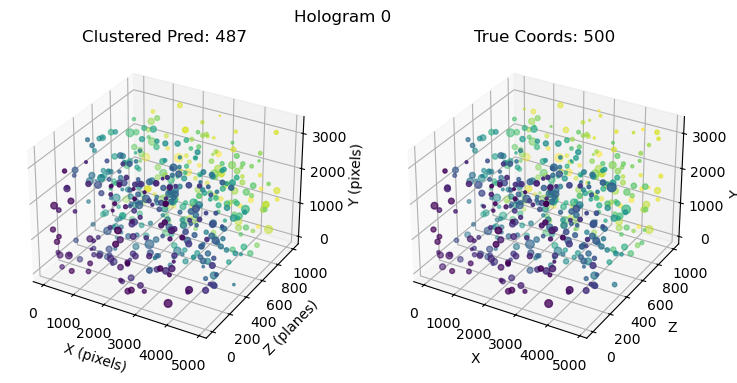

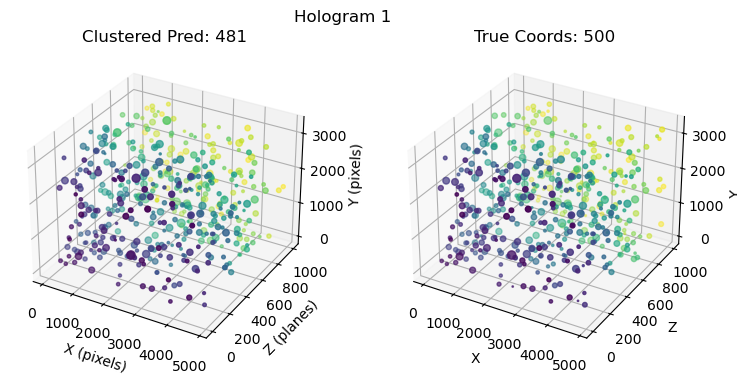

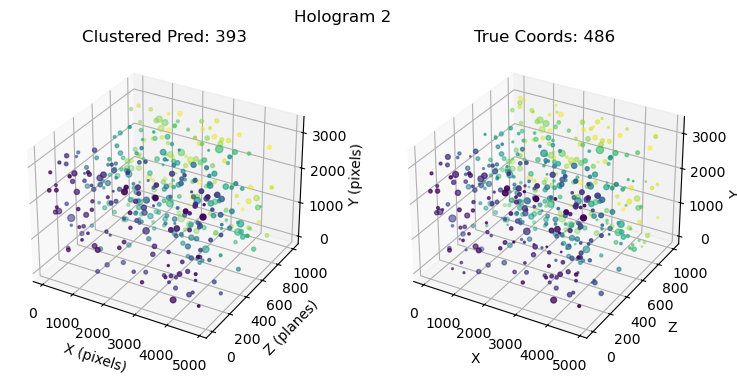

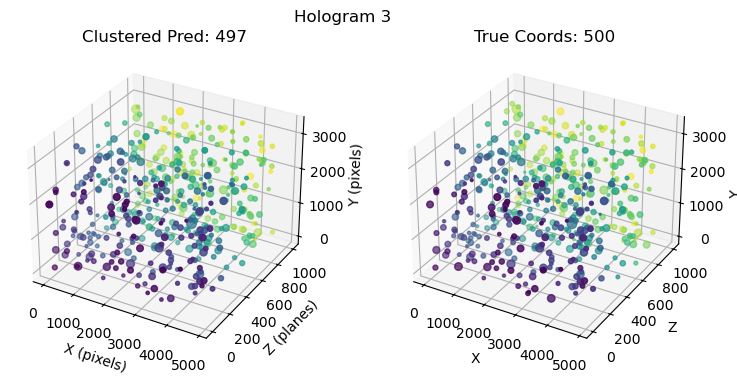

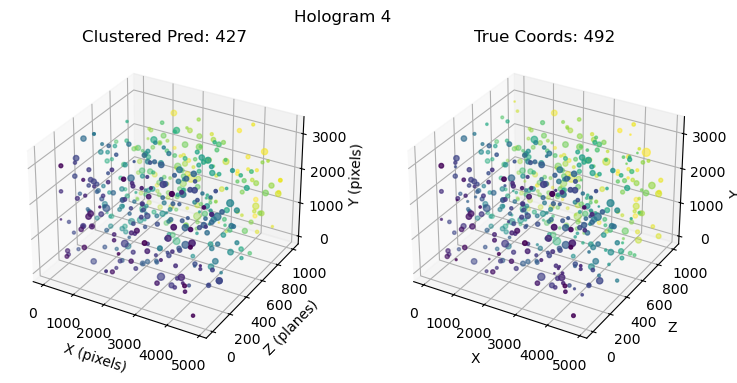

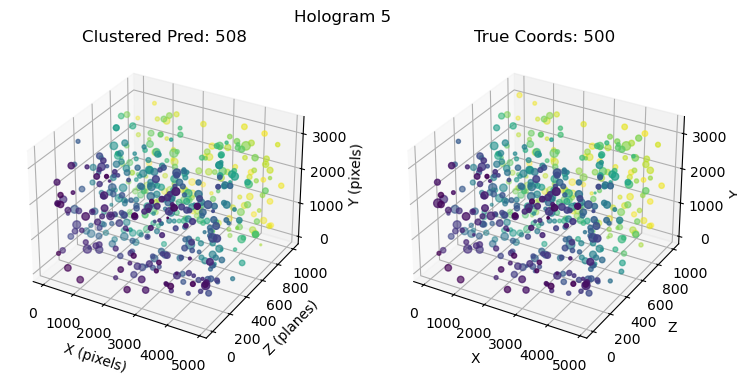

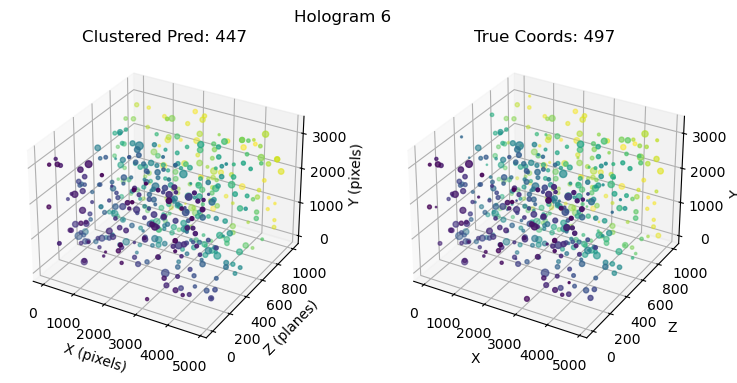

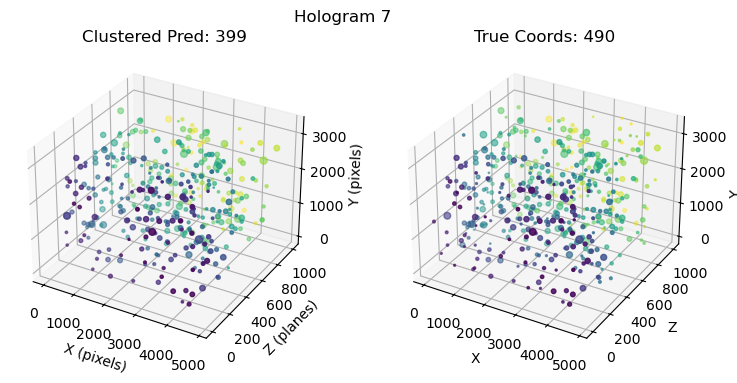

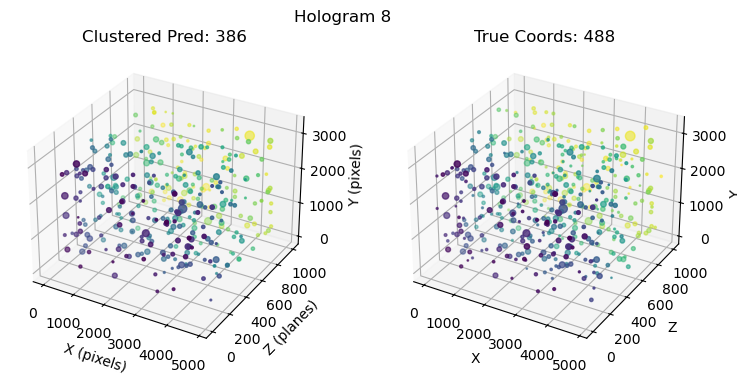

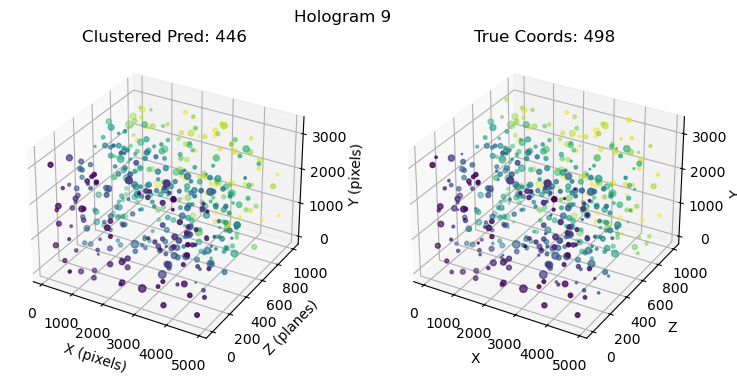

In [62]:
for idx, h_idx in enumerate(h_indeces):
    plot_duo_coords(split_pred[idx], split_truth[idx])


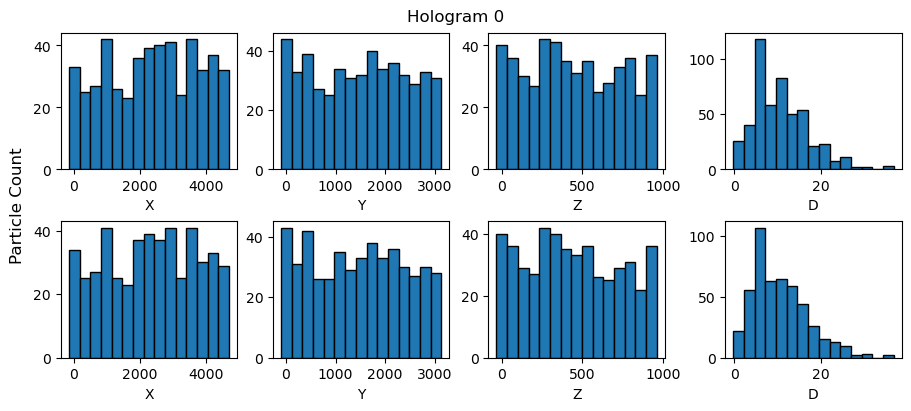

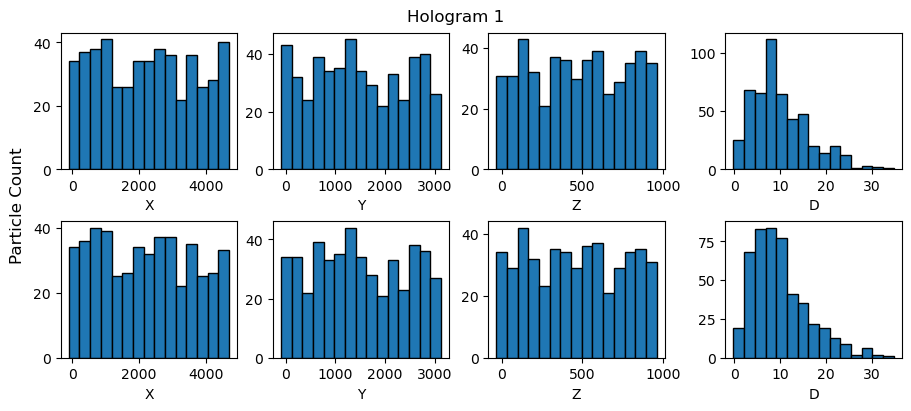

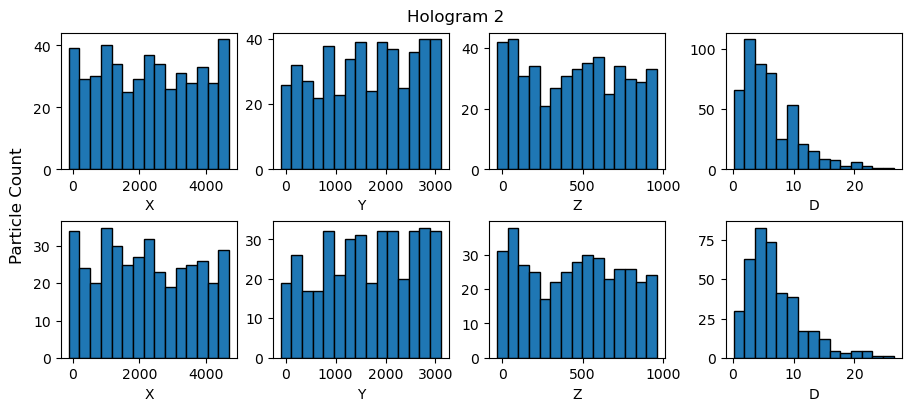

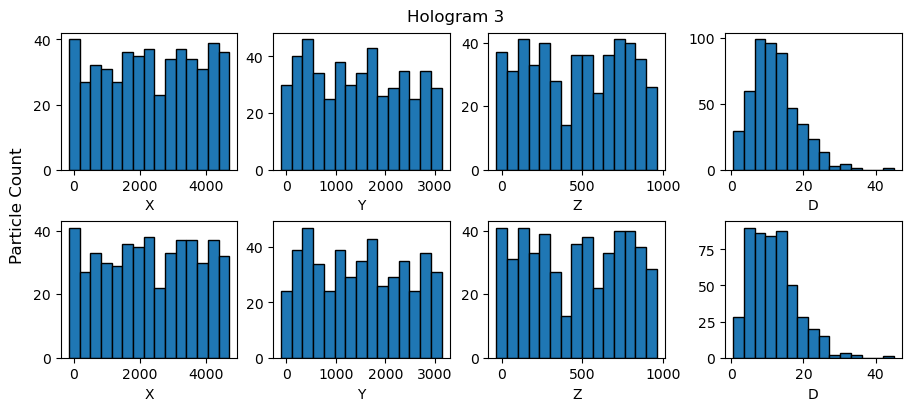

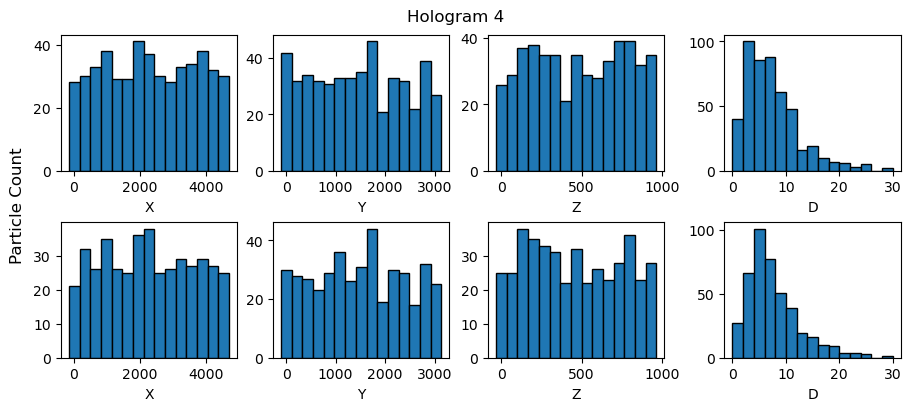

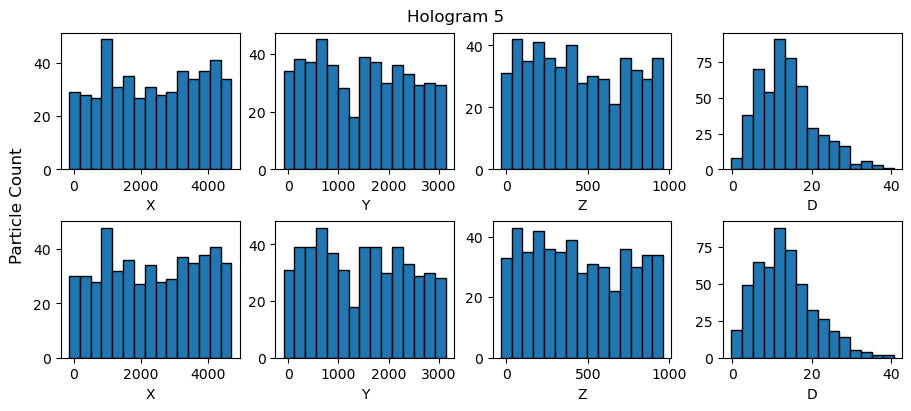

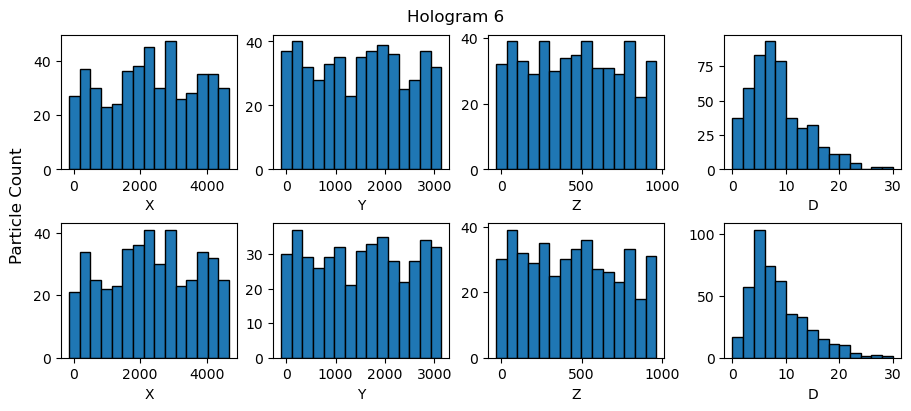

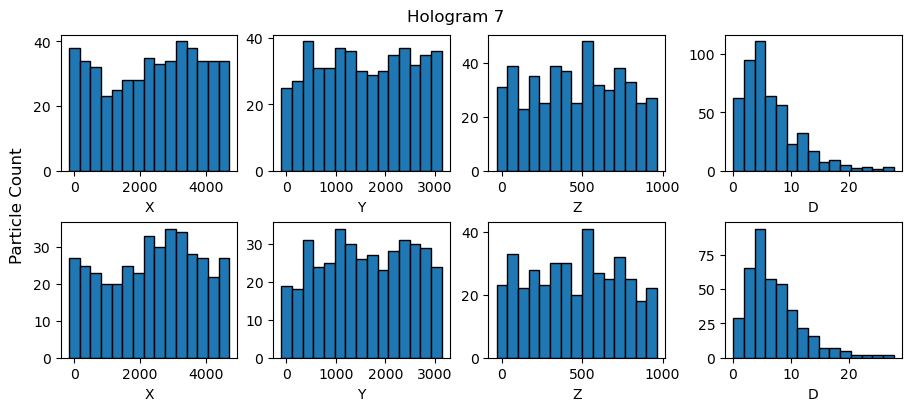

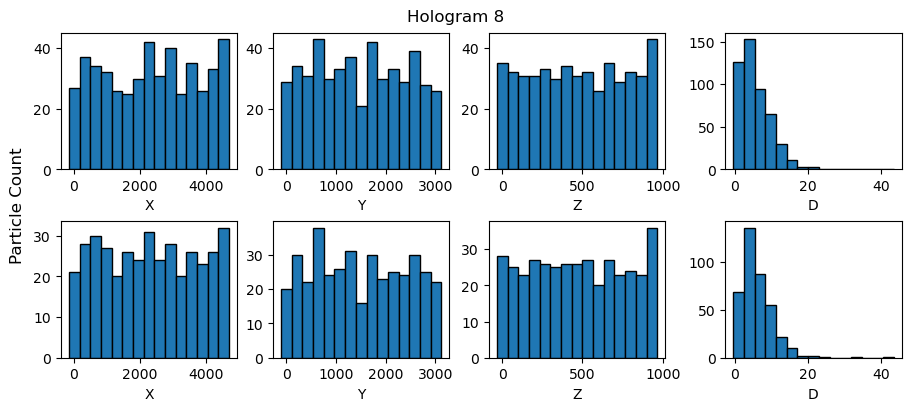

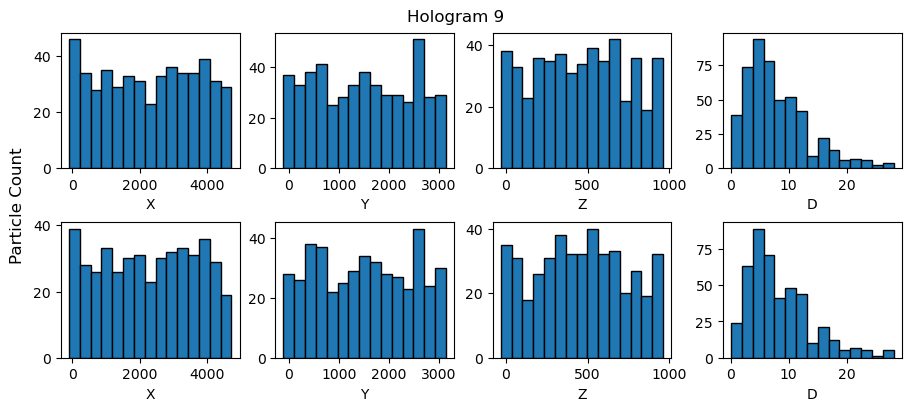

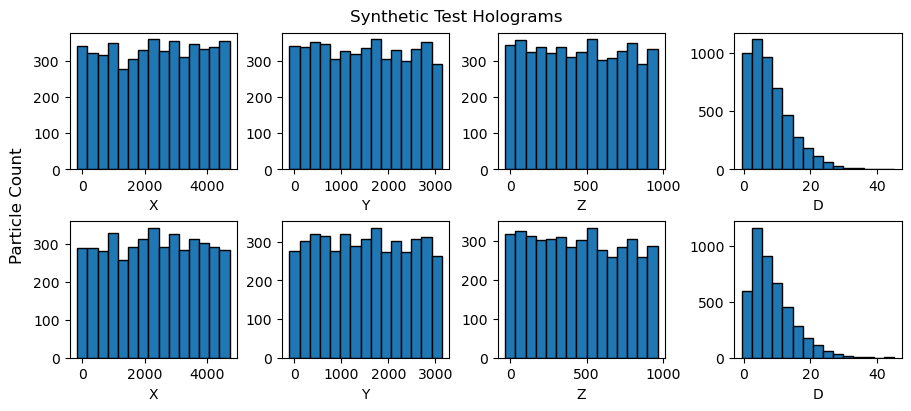

In [100]:
for idx, h_idx in enumerate(h_indeces):
    plot_duo_histograms(split_pred[idx], split_truth[idx], data_labels)
plot_duo_histograms(np.concatenate(split_pred, axis=0), np.concatenate(split_truth, axis=0), data_labels, all=True)

In [51]:
m2_list = []
m3_list = []
m32_list = []
for idx, h_idx in enumerate(h_indeces):
    m3_pred = moment(split_pred[idx][:,4], order=3)
    m3_true = moment(split_truth[idx][:,4], order=3)
    
    m2_pred = moment(split_pred[idx][:,4], order=2)
    m2_true = moment(split_truth[idx][:,4], order=2)
    
    print('Hologram %d: ' % h_idx)
    print(f'D_M2_Pred: {m2_pred}')
    print(f'D_M2_True: {m2_true}')
    print(f'D_M3_Pred: {m3_pred}')
    print(f'D_M3_True: {m3_true}')
    
    m2_list.append((m2_pred, m2_true))
    m3_list.append((m3_pred, m3_true))
    m32_list.append((m3_pred/m2_pred, m3_true/m2_true))

Hologram 0: 
D_M2_Pred: 41.148098653046745
D_M2_True: 42.761900000000004
D_M3_Pred: 240.93763198300277
D_M3_True: 289.568442
Hologram 1: 
D_M2_Pred: 38.717161439385976
D_M2_True: 37.583984
D_M3_Pred: 259.1365433723652
D_M3_True: 225.82499212800008
Hologram 2: 
D_M2_Pred: 20.178929107127058
D_M2_True: 21.52448390319904
D_M3_Pred: 117.24925687945829
D_M3_True: 125.17074976512146
Hologram 3: 
D_M2_Pred: 41.836618220388736
D_M2_True: 40.303564
D_M3_Pred: 246.19372631701324
D_M3_True: 235.01765563200001
Hologram 4: 
D_M2_Pred: 23.970961652958238
D_M2_True: 26.838732731839517
D_M3_Pred: 159.35789118977038
D_M3_True: 208.6986171801908
Hologram 5: 
D_M2_Pred: 54.72757781876675
D_M2_True: 52.665504
D_M3_Pred: 274.5740738728427
D_M3_True: 289.8779589120001
Hologram 6: 
D_M2_Pred: 26.276908074989393
D_M2_True: 27.87823925444012
D_M3_Pred: 151.98090411356003
D_M3_True: 149.77499409779654
Hologram 7: 
D_M2_Pred: 22.17873972036747
D_M2_True: 23.05357767596835
D_M3_Pred: 142.74002494259315
D_M3_True:

In [55]:
# Calculate some statistical differenes between m2/m3 over all, etc.
import pandas as pd

keys = ['Pred Parts', 'True Parts', 'Pred M2', 'True M2', 'Pred M3', 'True M3', 'Pred M3/M2', 'True M3/M2']

def diff_perc(row):
    m2_diff = abs(row[keys[3]] - row[keys[2]]) / row[keys[3]]
    m3_diff = abs(row[keys[5]] - row[keys[4]]) / row[keys[5]]
    m32_diff = abs(row[keys[7]]- row[keys[6]]) / row[keys[7]]
    return m2_diff, m3_diff, m32_diff

def diff_parts(row):
    return abs(row[keys[1]] - row[keys[0]]) / row[keys[1]]

part_counts = []
for idx, h_idx in enumerate(h_indeces):
    part_pred = len(split_pred[idx])
    part_true = len(split_truth[idx])
    part_counts.append((part_pred, part_true))

df = pd.DataFrame(part_counts, columns=keys[:2])
df = pd.concat([df, pd.DataFrame(m2_list, columns=keys[2:4])], axis=1)
df = pd.concat([df, pd.DataFrame(m3_list, columns=keys[4:6])], axis=1)
df = pd.concat([df, pd.DataFrame(m32_list, columns=keys[6:])], axis=1)
    
df['Perc_Diff Parts'] = df.apply(diff_parts, axis=1)
df['Perc_Diff M2'], df['Perc_Diff M3'], df['Perc_Diff M3/M2'] = zip(*df.apply(diff_perc, axis=1))

m2_rmse = root_mean_squared_error(df['Pred M2'], df['True M2'])
m3_rmse = root_mean_squared_error(df['Pred M3'], df['True M3'])
m32_rmse = root_mean_squared_error(df['Pred M3/M2'], df['True M3/M2'])

print(f'M2 RMSE: {m2_rmse}')
print(f'M3 RMSE: {m3_rmse}')
print(f'M3/M2 RMSE: {m32_rmse}')

mean_row = df.mean()
df.loc['mean_stats'] = mean_row

df


M2 RMSE: 1.649714042998199
M3 RMSE: 25.291390171689734
M3/M2 RMSE: 0.5711489244672666


,Pred Parts,True Parts,Pred M2,True M2,Pred M3,True M3,Pred M3/M2,True M3/M2,Perc_Diff Parts,Perc_Diff M2,Perc_Diff M3,Perc_Diff M3/M2
0,487.0,500.0,41.148099,42.761900,240.937632,289.568442,5.855377,6.771646,0.026000,0.037739,0.167942,0.135310
1,481.0,500.0,38.717161,37.583984,259.136543,225.824992,6.693067,6.008543,0.038000,0.030151,0.147510,0.113925
2,393.0,486.0,20.178929,21.524484,117.249257,125.170750,5.810480,5.815273,0.191358,0.062513,0.063285,0.000824
3,497.0,500.0,41.836618,40.303564,246.193726,235.017656,5.884647,5.831188,0.006000,0.038038,0.047554,0.009168
4,427.0,492.0,23.970962,26.838733,159.357891,208.698617,6.647956,7.776024,0.132114,0.106852,0.236421,0.145070
5,508.0,500.0,54.727578,52.665504,274.574074,289.877959,5.017106,5.504133,0.016000,0.039154,0.052794,0.088484
6,447.0,497.0,26.276908,27.878239,151.980904,149.774994,5.783820,5.372470,0.100604,0.057440,0.014728,0.076566
7,399.0,490.0,22.178740,23.053578,142.740025,147.958497,6.435894,6.418028,0.185714,0.037948,0.035270,0.002784
8,386.0,488.0,21.908050,23.272268,265.426020,271.201862,12.115456,11.653435,0.209016,0.058620,0.021297,0.039647
9,446.0,498.0,29.145969,30.370466,182.178497,182.493866,6.250556,6.008925,0.104418,0.040319,0.001728,0.040212


KS Statistic: 0.0700
P-value: 0.0000


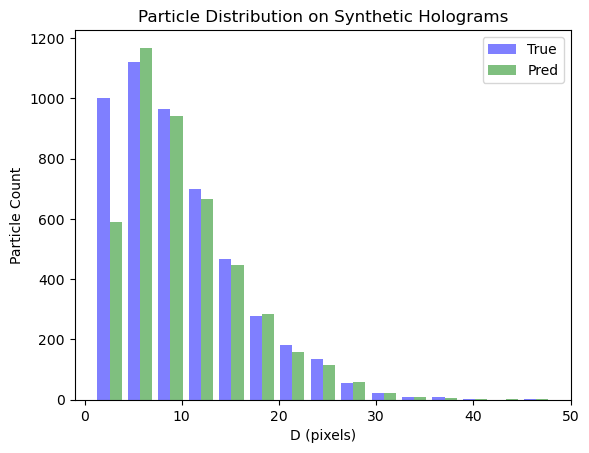

In [112]:
from scipy.stats import kstest
from scipy.stats import chisquare

all_pred = np.concatenate(split_pred, axis=0)
all_true = np.concatenate(split_truth, axis=0)

ks_statistic, p_value = kstest(all_pred[:,4], all_true[:,4])

#p_hist, p_edges = np.histogram(all_pred[:,4], bins=15)
#t_hist, t_edges = np.histogram(all_true[:,4], bins=15)
#chi2_statistic, p_value = chisquare(p_hist, f_exp=t_hist)

print(f"KS Statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

plt.hist([all_true[:,4],all_pred[:,4]], 15, alpha=0.5, label=['True', 'Pred'], color=['b', 'g'])
plt.legend(loc='upper right')
plt.title('Particle Distribution on Synthetic Holograms')
plt.xlabel('D (pixels)')
plt.ylabel('Particle Count')
plt.show()
